In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout
from sklearn.metrics import confusion_matrix, classification_report


In [3]:
train_dir = "data/train"
val_dir   = "data/val"
test_dir  = "data/test"
print("Training Classes :", os.listdir(train_dir))
print("Validation Classes :", os.listdir(val_dir))
print("Testing Classes :", os.listdir(test_dir))

Training Classes : ['Accident', 'Non Accident']
Validation Classes : ['Accident', 'Non Accident']
Testing Classes : ['Accident', 'Non Accident']


C:\Users\user\AppData\Local\Temp\ipykernel_19904\2899004567.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


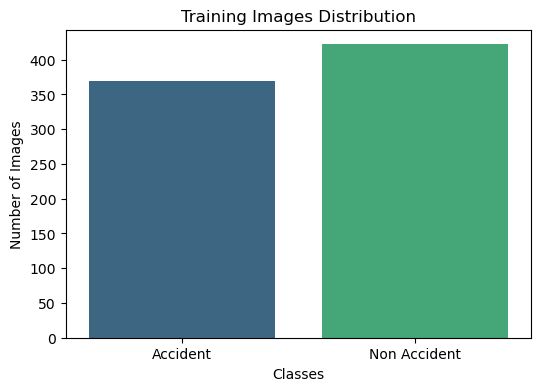

In [4]:
train_counts = []

classes = os.listdir(train_dir)

for cls in classes:
    train_counts.append(len(os.listdir(os.path.join(train_dir, cls))))

plt.figure(figsize=(6,4))

sns.barplot(
    x=classes,
    y=train_counts,
    palette="viridis"
)

plt.title("Training Images Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

In [5]:
# generators
train_ds = keras.utils.image_dataset_from_directory(
    directory = 'data/train',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(256,256)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = 'data/val',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(256,256)
)

test_ds = keras.utils.image_dataset_from_directory(
    directory = 'data/test',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(256,256)
)

Found 791 files belonging to 2 classes.
Found 98 files belonging to 2 classes.
Found 100 files belonging to 2 classes.


In [6]:
# Normalize
def process(image,label):
    image = tf.cast(image/255. ,tf.float32)
    return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)
test_ds = test_ds.map(process)

In [7]:
# create CNN model

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 254, 254, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 125, 125, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 60, 60, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 115200)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      14,745,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

# APPROACH 1 - FROM SCRATCH

In [9]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [10]:
history = model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10


C:\Users\user\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


25/25 ━━━━━━━━━━━━━━━━━━━━ 137s 5s/step - accuracy: 0.5537 - loss: 5.1140 - val_accuracy: 0.5408 - val_loss: 1.5173
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 156s 6s/step - accuracy: 0.6157 - loss: 4.2758 - val_accuracy: 0.4898 - val_loss: 6.6174
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 217s 6s/step - accuracy: 0.6764 - loss: 3.2957 - val_accuracy: 0.4694 - val_loss: 5.4689
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 162s 6s/step - accuracy: 0.6688 - loss: 2.6666 - val_accuracy: 0.5102 - val_loss: 2.2599
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 160s 6s/step - accuracy: 0.6802 - loss: 1.7093 - val_accuracy: 0.5306 - val_loss: 2.1936
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 161s 6s/step - accuracy: 0.7206 - loss: 1.3478 - val_accuracy: 0.5306 - val_loss: 3.1223
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 204s 6s/step - accuracy: 0.6941 - loss: 1.2587 - val_accuracy: 0.5816 - val_loss: 1.4871
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 200s 6s/step - accuracy: 0.7585 - loss: 0.9065 - val_accuracy: 0.6020 - val_loss: 1.

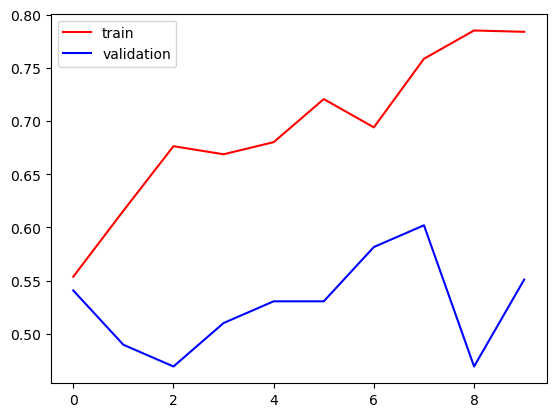

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

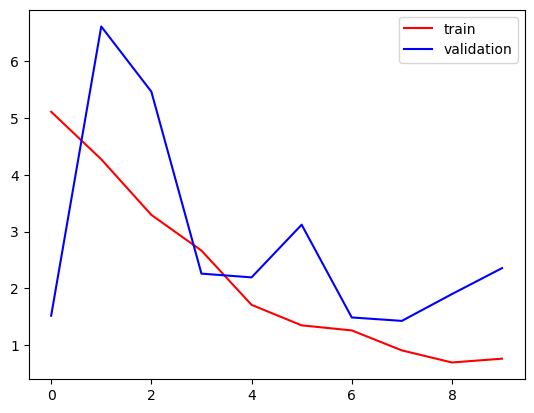

In [12]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [13]:
test_loss1, test_acc1 = model.evaluate(test_ds)

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 587ms/step - accuracy: 0.6200 - loss: 1.8168


# WITH PRETRAINED MODEL RESNET50

In [15]:
from tensorflow.keras.applications.resnet50 import ResNet50

IMG_SIZE = (224, 224)

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(256, 256, 3)
)
from tensorflow.keras import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D,Dense

model=Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128,activation='relu'),
    Dense(1,activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train Model

history_transfer = model.fit(
    train_ds,
    epochs=10,
    validation_data=validation_ds
)

test_loss2, test_acc2 = model.evaluate(test_ds)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 851s 31s/step - accuracy: 0.5942 - loss: 0.8522 - val_accuracy: 0.5306 - val_loss: 3099.4902
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 769s 31s/step - accuracy: 0.6587 - loss: 0.6189 - val_accuracy: 0.5306 - val_loss: 22.7104
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 808s 32s/step - accuracy: 0.7181 - loss: 0.5650 - val_accuracy: 0.4694 - val_loss: 25545.1719
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 812s 30s/step - accuracy: 0.7762 - loss: 0.4867 - val_accuracy: 0.5306 - val_loss: 5.1457
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 760s 30s/step - accuracy: 0.7826 - loss: 0.4607 - val_accuracy: 0.5306 - val_loss: 0.7886
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 792s 31s/step - accuracy: 0.8281 - loss: 0.3631 - val_accuracy: 0.5306 - val_loss: 14.0288
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 768s 31s/step - accuracy: 0.8685 - loss: 0.2856 - val_accuracy: 0.5306 - val_loss: 1.1168
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 822s 33s/step - accuracy: 0.8837 - loss: 0.2757 - val_acc

# WITH data augmentation 

In [16]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomZoom

data_augmentation=Sequential([

    RandomFlip("horizontal"),

    RandomRotation(0.2),

    RandomZoom(0.2)

])

In [17]:
model=Sequential([

    data_augmentation,

    base_model,

    GlobalAveragePooling2D(),

    Dense(128,activation='relu'),

    Dense(1,activation='sigmoid')

])

In [18]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',   # For binary classification
    metrics=['accuracy']
)

In [19]:
history_aug=model.fit(
    train_ds,
    epochs=10,
    validation_data=validation_ds
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 671s 24s/step - accuracy: 0.5461 - loss: 0.7346 - val_accuracy: 0.5306 - val_loss: 2.3989
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 587s 23s/step - accuracy: 0.5917 - loss: 0.6838 - val_accuracy: 0.4694 - val_loss: 164.7058
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 588s 24s/step - accuracy: 0.5967 - loss: 0.6692 - val_accuracy: 0.4694 - val_loss: 19.9040
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 635s 25s/step - accuracy: 0.5980 - loss: 0.6602 - val_accuracy: 0.5306 - val_loss: 1.4339
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 613s 25s/step - accuracy: 0.6485 - loss: 0.6327 - val_accuracy: 0.5306 - val_loss: 3.2268
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 616s 25s/step - accuracy: 0.6625 - loss: 0.6187 - val_accuracy: 0.5306 - val_loss: 6.2517
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 582s 23s/step - accuracy: 0.6561 - loss: 0.6210 - val_accuracy: 0.5306 - val_loss: 5.3638
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 629s 25s/step - accuracy: 0.6751 - loss: 0.6132 - val_accuracy:

In [20]:
test_loss3, test_acc3 = model.evaluate(test_ds)

4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.5300 - loss: 5.9593


# COMPARISON TABLE FOR ALL 3 APPROACHES

In [21]:
# How to Get These Accuracy Values Automatically
import pandas as pd

comparison = pd.DataFrame({

    'Model':[
        'CNN from Scratch',
        'ResNet50 (Transfer Learning)',
        'ResNet50 + Data Augmentation'
    ],

    'Training Accuracy (%)':[

        history.history['accuracy'][-1]*100,
        history_transfer.history['accuracy'][-1]*100,
        history_aug.history['accuracy'][-1]*100
    ],

    'Validation Accuracy (%)':[

        history.history['val_accuracy'][-1]*100,
        history_transfer.history['val_accuracy'][-1]*100,
        history_aug.history['val_accuracy'][-1]*100
    ],

    'Testing Accuracy (%)':[

        test_acc1*100,
        test_acc2*100,
        test_acc3*100
    ]

})

comparison = comparison.round(2)

print(comparison)

                          Model  Training Accuracy (%)  \
0              CNN from Scratch                  78.38   
1  ResNet50 (Transfer Learning)                  88.62   
2  ResNet50 + Data Augmentation                  67.26   

   Validation Accuracy (%)  Testing Accuracy (%)  
0                    55.10                  62.0  
1                    53.06                  53.0  
2                    53.06                  53.0  
